# 10章 コネクションと信頼性

本章では通信のコネクションと信頼性について学習します。
ここまで実装してきたのは、生成したパケットを一方的に送っていくコネクションレスと呼ばれる通信でした。
手軽に通信ができる一方で，パケットが相手に届く保証はありません。
これに対し、通信相手とメッセージ交換をして合意を得た上で、確実にパケットを届ける仕組みがコネクション型通信です。
本章では、それぞれの代表的なプロトコルであるUDPとTCPを実装していきます。

## コネクション型とコネクションレス型

### コネクションとは

コネクションとは、ネットワーク上での通信を行う際に、送信側と受信側が互いにデータの送受信準備ができている状態を確認し合うことです。
このプロセスを通じて、両者間での通信ルールやパラメタが合意され、データ交換がスムーズに行われるようになります。

### 信頼性とは

通信における信頼性とは、送信されたデータが確実に受信側に届き、かつ正しい順序で、正確に受け取られることを保証する性質のことを指します。
信頼性の高い通信では、データが途中で失われたり、乱れたりすることなく、確実に目的地に到達します。
信頼性は様々な要因によって影響・担保されますが、コネクションとも深く関連しています。

### コネクション型通信

コネクション型通信は、この信頼性を重視した通信方式です。
通信を開始する前に、送信側と受信側が接続を確立し、データの送受信が正しく行われたことを確認します。
この方式の大きなメリットは、データが確実に届くことが保証される点にあります。
また、データの順序が保持され、もし何らかの理由でデータが途中で失われた場合でも、自動的に再送されるため、安心して利用できます。
これらの特性から、Webページの閲覧やメールの送受信、ファイルのダウンロードなど、信頼性が求められる多くのインターネットサービスで採用されています。

### コネクションレス型通信

一方、コネクションレス型通信は、接続の確立プロセスを省略し、送信側がデータを受信側に直接送り出す方式です。
この方式の最大の特徴は、通信の手続きが簡単であり、データを素早く送ることができる点にあります。
信頼性はコネクション型ほど高くはありませんが、リアルタイム性が求められるビデオ通話やオンラインゲームなどのアプリケーションでは、遅延を小さくするためにコネクションレス型を用いることも多いです。

つまりコネクション型とコネクションレス型の選択は、使用するアプリケーションの要件によって異なります。
信頼性とデータの正確な到達を最優先する場合はコネクション型を、通信の速度やリアルタイム性を重視する場合はコネクションレス型を選ぶことが一般的です。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 443, done.
remote: Total 443 (delta 0), reused 0 (delta 0), pack-reused 443
Receiving objects: 100% (443/443), 116.50 KiB | 840.00 KiB/s, done.
Resolving deltas: 100% (326/326), done.


## UDPによるコネクションレス型通信

### UDPとは

UDP（User Datagram Protocol）は、コネクションレス型通信の代表的なプロトコルです。
OSI参照モデルのレイヤとしては、レイヤ4のトランスポート層に当たります。
このプロトコルの最大の特徴は、そのシンプルさと高速性にあります。
UDPではデータの送信前に送信側と受信側の間で合意を取りません。
ここまでに実装してきた通信アプリケーションは、明確に設計されてはいませんでしたが、大まかにはUDP的なコネクションレス型の通信でした。

UDPで送信されるデータは「データグラム」と呼ばれる小さなパケットに分割されます。
各データグラムは独立しており、ネットワークを通じて個別に送られます。
このため、データグラムが異なる経路を通って送信されることもあり、結果として受信側でのデータグラムの到着順序が入れ替わることがあります。
また、UDPはデータの到達を保証しないため、ネットワークの混雑などによりデータグラムが失われることもあります。

しかし、UDPのこのような特性は、一部のアプリケーションにとっては大きな利点となります。
例えば、ビデオチャットやオンラインゲームでは、わずかな遅延も許されないため、データが一部失われたとしても、次のデータグラムを迅速に受け取ることが重要です。
このような場合、UDPを使用することで、遅延を最小限に抑えつつ、効率的な通信が可能になります。
またUDPはヘッダ情報が少ないため、オーバーヘッドが小さく、帯域幅を節約できるというメリットもあります。
このため、放送やマルチキャストといった、同じデータを多くの受信者に送る必要がある場合にも適しています。

### ポート番号とは

UDPを扱うにあたって、ポート番号という概念が出てきます。
ポート番号は、インターネットやローカルネットワーク上でコンピュータ間でデータをやり取りする際に、どのアプリケーションがデータの送受信を行うかを識別するための数字です。
これはトランスポート層におけるアドレス情報に該当します。
つまり、IPアドレスがデータが届けられるべきコンピュータを特定するのに対し、ポート番号はそのコンピュータ内のどのアプリケーションにデータを渡すべきかを特定します。

ポート番号は0から65535までの範囲で設定され、このうち0から1023までの番号は「ウェルノウンポート」と呼ばれ、特定のサービスやプロトコルに予め割り当てられています。例えば、WebサーバのHTTP通信にはポート80が、HTTPS通信にはポート443が使われます。メールの送受信にはポート25（SMTP）、ポート110（POP3）、ポート143（IMAP）がそれぞれ用いられるなど、多くの標準的なインターネットサービスには固有のポート番号が割り当てられています。

1024から49151までのポート番号は「登録済みポート」として、特定のアプリケーションに割り当てることができますが、公式には特定のサービスに予約されているわけではありません。49152から65535までの範囲は「動的ポート」または「プライベートポート」と呼ばれ、クライアント側のアプリケーションが一時的な通信や内部的な用途で使用します。

ポート番号を使用することで、同じ物理的なコンピュータ上で複数の通信を同時に実行することが可能になります。例えば、あるサーバがWebサーバーとメールサーバの両方の機能を持っている場合、Webサーバへのリクエストはポート80に、メールサーバへのリクエストはポート25にそれぞれ送られます。サーバはポート番号を用いて受け取ったデータがどのサービス宛てかを識別し、データを渡すことができます。

### `UDPPacket`クラスの実装

`Packet`クラスを継承して、`UDPPacket`クラスを実装します。
主な目的は、UDPで用いるUDPヘッダ情報を付与することです。
コンストラクタ（`__init__`メソッド）では、`source_port`（送信元ポート番号）と`destination_port`（宛先ポート番号）を受け取るようにします。
これらのパラメタは、UDP通信においてデータが送られるべき送信元と宛先を識別するために必要です。
コンストラクタ内でこれらの値は`udp_header`という辞書に格納され、UDPヘッダ情報として管理されます。

`@property`デコレータを使用して定義されている`header`メソッドは、`UDPPacket`インスタンスのヘッダ情報を取得するためのものです。
このメソッドは、基底クラスである`Packet`から継承したMACヘッダとIPヘッダの情報（`mac_header`と`ip_header`）、そしてUDP特有のヘッダ情報（`udp_header`）を統合して返します。
つまりUDPパケットの全てのヘッダ情報を一度に取得することができます。

```
class UDPPacket(Packet):
    def __init__(self, source_port, destination_port, **kwargs):
        super().__init__(**kwargs)
        self.udp_header = {
            "source_port": source_port,
            "destination_port": destination_port
        }

    @property
    def header(self):
        # MACヘッダ、IPヘッダ、UDPヘッダを統合して返す
        return {**self.mac_header, **self.ip_header, **self.udp_header}
```

### `Node`クラスのアップデート

`UDPPacket`を送受信できるように、`Node`クラスをアップデートします。

#### トラフィック設定

まず、トラフィック設定時に、明示的にプロトコルを指定するように修正します。
また今後の実装のために、UDP用のトラフィック設定メソッドを定義します。
今回の実装では、簡単のためポート番号はランダムに選択することとしました。
なお、内容は従来のものとほぼ同様です。

```
# UDPトラフィックを開始する関数
def start_udp_traffic(self, destination_url, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0, protocol="UDP"):
    # トラフィックを開始するための内部関数
    def attempt_to_start_traffic():
        # 宛先URLからIPアドレスを解決
        destination_ip = self.resolve_destination_ip(destination_url)
        if destination_ip is None:
            # 宛先のIPアドレスが解決できなかった場合、DNSクエリを送信してトラフィック開始をスケジュール
            self.send_dns_query_and_set_traffic(destination_url, bitrate, start_time, duration, header_size, payload_size, burstiness, protocol)
        else:
            # 宛先のIPアドレスが既に解決できている場合、直接UDPトラフィックを開始
            self.set_udp_traffic(destination_ip, bitrate, start_time, duration, header_size, payload_size, burstiness, protocol)
    
    # トラフィック生成の開始時刻をスケジュール
    self.network_event_scheduler.schedule_event(start_time, attempt_to_start_traffic)

# 実際にUDPトラフィックを生成し、送信する関数
def set_udp_traffic(self, destination_ip, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0, protocol="UDP"):
    # トラフィック送信の終了時刻を計算
    end_time = start_time + duration
    # 送信元ポートをランダムに選択
    source_port = self.select_random_port()
    # 宛先ポートをランダムに選択（実際のアプリケーションでは具体的なポート番号が必要）
    destination_port = self.select_random_port()

    # パケットを生成し、送信する内部関数
    def generate_packet():
        # 現在時刻が送信終了時刻より前であればパケットを送信
        if self.network_event_scheduler.current_time < end_time:
            # ダミーデータを生成してパケットを送信
            data = b'X' * payload_size
            self.send_packet(destination_ip, data, protocol, source_port=source_port, destination_port=destination_port)

            # 次のパケット送信時刻を計算してスケジュール
            packet_size = header_size + payload_size
            interval = (packet_size * 8) / bitrate * burstiness
            self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time + interval, generate_packet)

    # すぐに最初のパケットを送信するためにスケジュール
    self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time, generate_packet)
```

#### パケットの生成と送信

トラフィック設定後にコールされるパケットの生成・送信処理についても、UDPパケットを生成するようにアップデートします。
基本的な内容は変わらないのですが、本章での拡張を踏まえて少し整理してあります。

```
# パケット送信メソッドの定義
def send_packet(self, destination_ip, data, protocol="UDP", **kwargs):
    """
    汎用的なパケット送信メソッド。プロトコルに基づいて適切なパケットを送信します。
    """
    # 宛先IPアドレスに対応するMACアドレスを取得
    destination_mac = self.get_mac_address_from_ip(destination_ip)

    # 宛先MACアドレスが未解決の場合
    if destination_mac is None:
        # ARPリクエストを送信し、宛先MACアドレスの解決を試みる
        self.send_arp_request(destination_ip)
        # パケット送信を待機リストに追加（MACアドレス解決後に送信を試みる）
        if destination_ip not in self.waiting_for_arp_reply:
            self.waiting_for_arp_reply[destination_ip] = []
        self.waiting_for_arp_reply[destination_ip].append((data, protocol, kwargs))
    else:
        # 宛先MACアドレスが解決済みの場合
        if protocol == "UDP":
            # UDPプロトコルを使用してパケットを送信
            self._send_udp_packet(destination_ip, destination_mac, data, **kwargs)

# UDPパケット送信メソッドの定義
def _send_udp_packet(self, destination_ip, destination_mac, data, **kwargs):
    """
    UDPパケットを送信するための内部メソッド。
    """
    # UDPヘッダとIPヘッダのサイズを計算
    udp_header_size = 8  # UDPヘッダは8バイト
    ip_header_size = 20  # IPヘッダは20バイト
    header_size = udp_header_size + ip_header_size
    # IPパケット送信メソッドを呼び出してUDPパケットを送信
    self._send_ip_packet_data(destination_ip, destination_mac, data, header_size, protocol="UDP", **kwargs)

# IPパケット送信メソッドの定義
def _send_ip_packet_data(self, destination_ip, destination_mac, data, header_size, protocol, **kwargs):
    """
    IPパケットを送信するための内部メソッド。
    """
    # パケットIDを生成
    original_data_id = str(uuid.uuid4())
    # データが空の場合でもループを一度実行するために1を設定
    total_size = len(data) if data else 1
    offset = 0

    # データをフラグメントして送信
    while offset < total_size:
        # このフラグメントのペイロードサイズを計算
        max_payload_size = self.mtu - header_size
        payload_size = min(max_payload_size, total_size - offset) if data else 0
        # フラグメントデータを切り出し
        fragment_data = data[offset:offset + payload_size] if data else b""
        fragment_offset = offset

        # フラグメントフラグを設定
        more_fragments = offset + payload_size < total_size
        fragment_flags = {"more_fragments": more_fragments, "original_data_id": original_data_id}

        # プロトコルに応じたパケットオブジェクトを生成
        if protocol == "UDP":
            packet = UDPPacket(source_mac=self.mac_address, destination_mac=destination_mac, source_ip=self.ip_address, destination_ip=destination_ip, ttl=64, network_event_scheduler=self.network_event_scheduler, fragment_flags=fragment_flags, fragment_offset=fragment_offset, header_size=header_size, payload_size=payload_size, source_port=kwargs.get('source_port'), destination_port=kwargs.get('destination_port'))
        # パケットのペイロードにフラグメントデータを設定し、パケットを送信
        packet.payload = fragment_data
        self._send_packet(packet)

        # データが空の場合はループを抜ける
        if not data:
            break

        # 次のフラグメントのオフセットへ
        offset += payload_size
```

##### パケットの受信

パケットの種類が増えてきたので、`receive_packet`メソッドを整理した上で、`UDPPacket`受信時の処理を実装します。
`process_UDP_packet`メソッドで`UDPPacket`の受信処理を実行します。
なおフラグメント等の扱いについては、従来と同じです。

```
# パケット受信メソッドの定義
def receive_packet(self, packet, received_link):
    # パケットがロストした場合
    if packet.arrival_time == -1:
        # パケットのロスト情報をログに記録
        self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)
    elif isinstance(packet, ARPPacket):  # ARPパケットを受信した場合
        # ARPパケット処理メソッドを呼び出し
        self.process_ARP_packet(packet)
    elif isinstance(packet, DHCPPacket):  # DHCPパケットを受信した場合
        # DHCPパケット処理メソッドを呼び出し
        self.process_DHCP_packet(packet)
    elif isinstance(packet, DNSPacket):  # DNSパケットを受信した場合
        # DNSパケット処理メソッドを呼び出し
        self.process_DNS_packet(packet)
    elif isinstance(packet, UDPPacket):  # UDPパケットを受信した場合
        # UDPパケット処理メソッドを呼び出し
        self.process_UDP_packet(packet)
    else:
        # 未知のパケットタイプの場合、ドロップ情報をログに記録
        self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)

# UDPパケット処理メソッドの定義
def process_UDP_packet(self, packet):
    # パケットの宛先MACアドレスがこのノードのMACアドレスと一致するか確認
    if packet.header["destination_mac"] == self.mac_address:
        # パケットの宛先IPアドレスがこのノードのIPアドレスと一致するか確認
        if packet.header["destination_ip"] == self.ip_address:
            # データパケット処理メソッドを呼び出し
            self.process_data_packet(packet)
        else:
            # 宛先IPアドレスが一致しない場合、ドロップ情報をログに記録
            self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)

# データパケット処理メソッドの定義
def process_data_packet(self, packet):
    # パケットが正常に到着したことをログに記録
    self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
    # パケットの到着時刻を設定
    packet.set_arrived(self.network_event_scheduler.current_time)

    # パケットがフラグメントされているか確認
    more_fragments = packet.header.get("fragment_flags", {}).get("more_fragments", False)
    if more_fragments:
        # フラグメントされたパケットを一時保存
        self._store_fragment(packet)
    else:
        # フラグメントされていない、または最後のフラグメントの場合、パケットを再構築して処理
        self._reassemble_and_process_packet(packet)
```


### UDPのシミュレーション

UDPトラフィックのシミュレーションを実行してテストしてみましょう。
ここまでに実装してきた機能を、改めてUDPとして定義し直しただけなので、前章とほとんど変わりません。
テストコードでは、トラフィックは以下のように設定しています。

```
# 通信アプリケーションの設定
node1.start_udp_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000)
```


Cloning into 'network-simulator'...
remote: Enumerating objects: 935, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 935 (delta 12), reused 14 (delta 6), pack-reused 915
Receiving objects: 100% (935/935), 187.57 KiB | 2.37 MiB/s, done.
Resolving deltas: 100% (702/702), done.


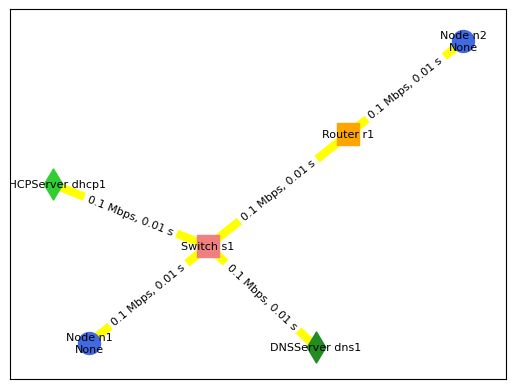

Time: 0.01 Node: n1, Event: dropped, Packet: 6397927c-5642-4863-b123-d0c0656e891b, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: r1, Event: dropped BPDU, Packet: c11b8b74-4238-46ae-bbc5-98de89d06ad1, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: dns1, Event: dropped, Packet: 7c5ed127-cb37-4232-9529-51d2dd971143, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: n1, Event: dropped, Packet: 58c5fe66-df34-4666-a4c6-d41257e7c71e, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: r1, Event: dropped BPDU, Packet: f83562f6-4ce6-4bb2-8f82-e8130c5e28e8, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: dns1, Event: dropped, Packet: 35bfa3e0-2352-49ae-9710-e4ee7295bd20, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0212 Node: n1, Event: dropped, Packet: 3073a425-dc06-4529-b6da-3d6253e7a156, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0212 Node: r1, Event: dropped BPDU, Packet: 697fa439-d881-4254-9a1e-6d13bfd7182d, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.026799999999999997 Node: n1, Event:

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec10a.NetworkEventScheduler import NetworkEventScheduler
from sec10a.Node import Node
from sec10a.Switch import Switch
from sec10a.Router import Router
from sec10a.Server import DNSServer, DHCPServer
from sec10a.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_udp_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_url_to_ip_mapping()
router1.print_arp_table()
router1.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


## TCPによるコネクション型通信

### TCPとは

TCP（Transmission Control Protocol）は、UDPと同じくトランスポート層に属するプロトコルです。
TCPはコネクション型のプロトコルであり、通信の信頼性を重視しています。
このため、リアルタイム性よりもデータの正確性が求められるWebサイトの閲覧、ファイル転送、電子メールの送受信などに適しています。
なおトランスポート層は、「データをどのように送るか」という論理的な方法を規定します。
これは、物理層からネットワーク層までがあくまで物理的な転送経路を規定していたのとは対照的です。

UDPとは異なり、TCPは信頼性の高い通信を実現するために設計されており、データが正確に、順序正しく、エラーなく目的地に届くことを保証します。
この信頼性を担保するのが、データ送信の際に確立されるコネクションという仕組みです。
コネクションとは、通信を行うエンドノード間での一時的な通信路のことです。
TCPでは、データの送受信を開始する前に、送信側と受信側の間でコネクションを確立します。
このプロセスを3ウェイハンドシェイクと呼びます。
3ウェイハンドシェイクを通じて、両端点は互いに通信の準備ができていることを確認し、データ送受信のためのパラメタを交換します。

### `TCPPacket`クラスの実装

UDPのときと同じように、`TCPPacket`クラスを作成します。
TCPヘッダには様々な情報が含まれるのですが、その中で学習が必須なものを選んで実装していきます。
ただし後の章で使うものもあるため、ここではポート番号と、制御フラグを表す`flags`だけ理解しておけば十分です。
TCPヘッダ内には、あらかじめ専用の制御フラグを表すフィールドが定義されており、各フィールドの値を変えることで、通常のデータパケットと、コネクション確立用のパケットなどを区別します。

```
class TCPPacket(Packet):
    # TCPPacketクラスの初期化メソッド
    def __init__(self, source_port, destination_port, sequence_number, acknowledgment_number, flags, **kwargs):
        # Packetクラス（親クラス）の初期化メソッドを呼び出し
        super().__init__(**kwargs)
        
        # TCPヘッダ情報を辞書型で定義
        self.tcp_header = {
            "source_port": source_port,  # 送信元ポート番号
            "destination_port": destination_port,  # 宛先ポート番号
            "sequence_number": sequence_number,  # シーケンス番号（送信データの順序を保証するための番号）
            "acknowledgment_number": acknowledgment_number,  # 確認応答番号（受信確認と次に期待するシーケンス番号を示す）
            "flags": flags  # 制御フラグ（通信の制御情報、例えばSYN, ACKなど）
        }

    @property
    def header(self):
        # パケットのヘッダ情報を取得するプロパティ
        # MACヘッダ、IPヘッダ、TCPヘッダを統合しパケット全体のヘッダ情報を一括で取得できる
        return {**self.mac_header, **self.ip_header, **self.tcp_header}
```

### `Node`クラスのアップデート

`TCPPacket`を送信できるように、`Node`クラスをアップデートします。
トラフィック設定については、本章の範囲ではUDPとほぼ同様のため説明を省略します。
ここでは特に、コネクションを確立するプロセスを実装していきます。

#### パケット送信を開始

プロトコルがTCPである場合、まずコネクションが確立されているかをチェックし、未確立の場合には3ウェイハンドシェイクを開始します。

```
def send_packet(self, destination_ip, data, protocol="UDP", **kwargs):
    """
    このメソッドは、指定された宛先IPアドレスにデータパケットを送信するためのものです。
    プロトコル（UDPまたはTCP）に基づいて、適切な送信処理を行います。
    """
    # 宛先IPアドレスから対応するMACアドレスを取得します。
    destination_mac = self.get_mac_address_from_ip(destination_ip)

    # 宛先MACアドレスが未知の場合、ARPリクエストを送信してMACアドレスを解決します。
    if destination_mac is None:
        self.send_arp_request(destination_ip)
        # ARPリクエストの結果を待つ間、送信予定のパケットを一時的に保存します。
        if destination_ip not in self.waiting_for_arp_reply:
            self.waiting_for_arp_reply[destination_ip] = []
        self.waiting_for_arp_reply[destination_ip].append((data, protocol, kwargs))
    else:
        # 宛先MACアドレスが既知の場合、プロトコルに応じた送信メソッドを呼び出します。
        if protocol == "UDP":
            self._send_udp_packet(destination_ip, destination_mac, data, **kwargs)
        elif protocol == "TCP":
            # TCPの場合、接続が確立しているかを確認します。
            if not self.is_tcp_connection_established(destination_ip, kwargs.get('destination_port')):
                # 接続が未確立の場合、3ウェイハンドシェイクを開始します。
                # この際、送信予定のデータを一時的に保存します。
                connection_key = (destination_ip, kwargs.get('destination_port'))
                self.pending_tcp_data[connection_key] = {"data": data, "kwargs": kwargs}
                self.initiate_tcp_handshake(destination_ip, destination_mac, **kwargs)
            else:
                # 接続が確立している場合、データパケットを送信します。
                self._send_tcp_packet(destination_ip, destination_mac, data, **kwargs)
```

#### コネクションの開始

コネクションのチェックや更新に関するメソッドを実装しておきます。
また、3ウェイハンドシェイクの開始時には、SYNフラグをセットしたコントロールパケットを送信します。
ここでコントロールパケットとは、本来送信したいデータを含まない、制御用の情報のみを格納したパケットを指します。

```
def is_tcp_connection_established(self, destination_ip, destination_port):
    """
    指定された宛先IPとポートに対するTCP接続が確立しているかどうかを確認します。
    """
    key = (destination_ip, destination_port)
    return self.tcp_connections.get(key, {}).get("state") == "ESTABLISHED"

def update_tcp_connection_state(self, destination_ip, destination_port, new_state):
    """
    指定された宛先に対するTCP接続の状態を更新します。
    """
    key = (destination_ip, destination_port)
    self.tcp_connections[key] = {"state": new_state}
    if self.network_event_scheduler.tcp_verbose:
        print(f"TCP connection state updated to {new_state} for {destination_ip}:{destination_port}")

def initiate_tcp_handshake(self, destination_ip, destination_mac, **kwargs):
    """
    TCPの3ウェイハンドシェイクを開始します。最初のSYNパケットを送信して、
    接続確立のプロセスを開始します。
    """
    if not self.is_tcp_connection_established(destination_ip, kwargs.get('destination_port')):
        # 接続が未確立の場合、SYNフラグを持つTCPパケットを送信してハンドシェイクを開始します。
        if self.network_event_scheduler.tcp_verbose:
            print(f"Initiating TCP handshake: Sending SYN to {destination_ip}:{kwargs.get('destination_port')} from port {kwargs.get('source_port')}")
        control_packet_kwargs = kwargs.copy()
        control_packet_kwargs.update({
            "flags": "SYN",  # SYNフラグをセット
            "payload_size": 0  # コントロールパケットにはペイロードは不要
        })
        self.update_tcp_connection_state(destination_ip, kwargs.get('destination_port'), "SYN_SENT")
        self._send_tcp_packet(destination_ip, destination_mac, b"", **control_packet_kwargs)
```

#### パケットの送信

既存のパケット送信メソッドをアップデートします。
通常のデータパケットでも、制御用のコントロールパケットでも問題なく送信できるようにします。

```
def _send_tcp_packet(self, destination_ip, destination_mac, data, **kwargs):
    """
    TCPプロトコルを使用してパケットを送信します。このメソッドは、TCPヘッダとIPヘッダのサイズを考慮して、
    パケットのフラグメント処理を行いながら送信を行います。
    """
    # TCPヘッダとIPヘッダのサイズを定義します。
    tcp_header_size = 20  # TCPヘッダは通常20バイトです。
    ip_header_size = 20  # IPヘッダも通常20バイトです。
    # ヘッダの合計サイズを計算します。
    header_size = tcp_header_size + ip_header_size

    # 実際のパケット送信処理を行います。
    self._send_ip_packet_data(destination_ip, destination_mac, data, header_size, protocol="TCP", **kwargs)

def _send_ip_packet_data(self, destination_ip, destination_mac, data, header_size, protocol, **kwargs):
    """
    IPパケットを送信するための内部メソッドです。このメソッドは、TCPまたはUDPプロトコルに基づいて、
    適切なパケットを生成し、必要に応じてフラグメント処理を行います。
    """
    # パケットの一意なIDを生成します。
    original_data_id = str(uuid.uuid4())
    # データが空の場合でも、ループを一度は実行するために、total_sizeを1に設定します。
    total_size = len(data) if data else 1
    offset = 0

    while offset < total_size:
        # このフラグメントの最大ペイロードサイズを計算します。
        max_payload_size = self.mtu - header_size
        # 実際のペイロードサイズは、残りのデータサイズと最大ペイロードサイズの小さい方です。
        payload_size = min(max_payload_size, total_size - offset) if data else 0
        # フラグメントデータを切り出します。
        fragment_data = data[offset:offset + payload_size] if data else b""
        fragment_offset = offset

        # フラグメントフラグを設定します。
        more_fragments = offset + payload_size < total_size
        fragment_flags = {
            "more_fragments": more_fragments,
            "original_data_id": original_data_id
        }

        # プロトコルに応じて適切なパケットクラスを使用してパケットを生成します。
        if protocol == "UDP":
            packet = UDPPacket(
                source_mac=self.mac_address,
                destination_mac=destination_mac,
                source_ip=self.ip_address,
                destination_ip=destination_ip,
                ttl=64,
                network_event_scheduler=self.network_event_scheduler,
                fragment_flags=fragment_flags,
                fragment_offset=fragment_offset,
                header_size=header_size,
                payload_size=payload_size,
                source_port=kwargs.get('source_port'),
                destination_port=kwargs.get('destination_port')
            )
        elif protocol == "TCP":
            packet = TCPPacket(
                source_mac=self.mac_address,
                destination_mac=destination_mac,
                source_ip=self.ip_address,
                destination_ip=destination_ip,
                ttl=64,
                network_event_scheduler=self.network_event_scheduler,
                fragment_flags=fragment_flags,
                fragment_offset=fragment_offset,
                header_size=header_size,
                payload_size=payload_size,
                source_port=kwargs.get('source_port'),
                destination_port=kwargs.get('destination_port'),
                sequence_number=kwargs.get('sequence_number', ''),
                acknowledgment_number=kwargs.get('acknowledgment_number', ''),
                flags=kwargs.get('flags', '')
            )

        # パケットにペイロードを設定し、送信します。
        packet.payload = fragment_data
        self._send_packet(packet)

        # データが空の場合、ループから抜けます。
        if not data:
            break

        # 次のフラグメントのためにオフセットを更新します。
        offset += payload_size
```

#### パケットの受信

パケット受信メソッドに、`TCPPacket`に対する処理を付け加えます。
`TCPPacket`を処理する`process_TCP_packet`メソッドでは、パケットに設定されたフラグに応じて異なるメソッドをコールします。
具体的には、SYNパケットを受信した場合、`send_TCP_SYN_ACK`によりSYN-ACKを送信します。
SYN_ACKに対しては`send_TCP_ACK`によりACKパケットを生成して送信し、`establish_TCP_connection`メソッドにより3ウェイハンドシェイクを完了させます。
また、ACKパケットを受け取った際にも、コネクションを確立状態にします。

```
def receive_packet(self, packet, received_link):
    """
    受信したパケットを処理するメソッドです。パケットの種類に応じて適切な処理関数を呼び出します。
    """
    if packet.arrival_time == -1:
        # パケットが失われた場合の処理
        self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)
    elif isinstance(packet, ARPPacket):
        # ARPパケットの処理
        self.process_ARP_packet(packet)
    elif isinstance(packet, DHCPPacket):
        # DHCPパケットの処理
        self.process_DHCP_packet(packet)
    elif isinstance(packet, DNSPacket):
        # DNSパケットの処理
        self.process_DNS_packet(packet)
    elif isinstance(packet, UDPPacket):
        # UDPパケットの処理
        self.process_UDP_packet(packet)
    elif isinstance(packet, TCPPacket):
        # TCPパケットの処理
        self.process_TCP_packet(packet)
    else:
        # 未知のパケットタイプの場合、ドロップする
        self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)

def process_TCP_packet(self, packet):
    """
    TCPパケットを処理するメソッドです。パケットのフラグを確認し、適切な応答を行います。
    """
    if packet.header["destination_mac"] == self.mac_address and packet.header["destination_ip"] == self.ip_address:
        # TCPフラグを確認して適切な処理を行う
        flags = packet.header.get('flags', '')  # flagsがNoneの場合、デフォルト値として空文字列を使用
        if "SYN" in flags and "ACK" not in flags:
            # SYNパケットを受信した場合、SYN-ACKを送信
            self.send_TCP_SYN_ACK(packet)
        elif "SYN" in flags and "ACK" in flags:
            # SYN-ACKパケットを受信した場合、ACKを送信して接続を確立
            self.send_TCP_ACK(packet, final_ack=True)
        elif "ACK" in flags:
            # ACKパケットを受信した場合、接続が確立されたとみなす
            self.establish_TCP_connection(packet)
        elif "FIN" in flags:
            # FINパケットを受信した場合、接続を終了
            self.terminate_TCP_connection(packet)
        elif "PSH" in flags or "PSH-ACK" in flags:
            # データ転送パケット（PSH）を受信した場合、データを処理
            self.process_data_packet(packet)
        else:
            # その他のフラグの場合、データパケットとして処理
            self.process_data_packet(packet)
    else:
        # 宛先がこのノードではない場合、パケットをドロップ
        self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)

def send_TCP_SYN_ACK(self, packet):
    """
    SYN-ACKパケットを送信する処理です。SYNパケットを受信した後に、この応答を送ります。
    """
    # ログ出力とデバッグ情報の表示
    self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
    if self.network_event_scheduler.tcp_verbose:
        print(f"Sending SYN-ACK to {packet.header['source_ip']}:{packet.header['source_port']}")
    # SYN-ACKパケットのフラグ設定
    syn_ack_packet_flags = "SYN,ACK"
    # SYN-ACKパケットの送信
    self._send_tcp_packet(
        destination_ip=packet.header["source_ip"],
        destination_mac=packet.header["source_mac"],
        data="",
        flags=syn_ack_packet_flags,
        source_port=packet.header["destination_port"],
        destination_port=packet.header["source_port"]
    )

def send_TCP_ACK(self, packet, final_ack=False):
    """
    ACKパケットを送信してTCP接続を確立する処理です。SYN-ACKパケットに対する応答として、またはデータ転送完了後に送ります。
    """
    # ログ出力とデバッグ情報の表示
    self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
    if self.network_event_scheduler.tcp_verbose:
        print(f"Sending ACK to {packet.header['source_ip']}:{packet.header['source_port']}, Final ACK: {final_ack}")
    # ACKパケットのフラグ設定
    ack_packet_flags = "ACK"
    # ACKパケットの送信
    self._send_tcp_packet(
        destination_ip=packet.header["source_ip"],
        destination_mac=packet.header["source_mac"],
        data="",
        flags=ack_packet_flags,
        source_port=packet.header["destination_port"],
        destination_port=packet.header["source_port"]
    )
    if final_ack:
        # 最終的なACKの後に接続を確立する処理
        self.establish_TCP_connection(packet)

def establish_TCP_connection(self, packet):
    """
    TCP接続を確立する処理です。接続が確立されたら、保存しておいたデータがあれば送信します。
    """
    connection_key = (packet.header["source_ip"], packet.header["source_port"])
    
    # すでに接続が確立されている場合は、この処理をスキップします。
    if self.is_tcp_connection_established(*connection_key):
        return

    # ログ出力とデバッグ情報の表示
    self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
    packet.set_arrived(self.network_event_scheduler.current_time)
    if self.network_event_scheduler.tcp_verbose:
        print(f"Establishing TCP connection with {packet.header['source_ip']}:{packet.header['source_port']}")

    # 接続状態を「ESTABLISHED」に更新します。
    self.update_tcp_connection_state(*connection_key, "ESTABLISHED")

    # 保存しておいたデータがあれば送信します。
    if connection_key in self.pending_tcp_data:
        pending_data = self.pending_tcp_data.pop(connection_key)
        data_to_send = pending_data["data"]
        kwargs_to_use = pending_data["kwargs"]
        self._send_tcp_packet(packet.header["source_ip"], packet.header["source_mac"], data_to_send, **kwargs_to_use)
```


### TCPのシミュレーション

TCPトラフィックのシミュレーションを実行してテストしてみましょう。
今回はTCPのコネクション確立を実装したので、とりあえず以下のようなコードで適当にトラフィックを設定してみましょう。

```
node1.start_tcp_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000)
```

TCPに関する詳細なログは、以下のように`tcp_verbose`オプションで表示することができます。

```
nes = NetworkEventScheduler(log_enabled=True, verbose=True, tcp_verbose=True)
```


fatal: destination path 'network-simulator' already exists and is not an empty directory.


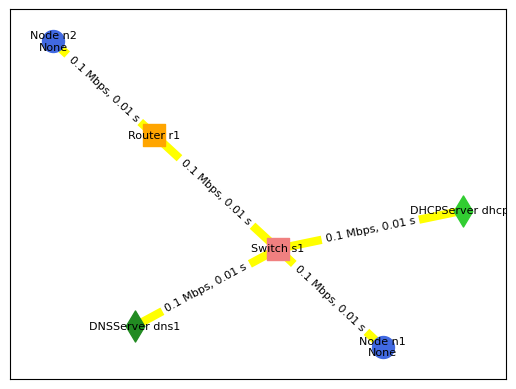

Time: 0.01 Node: n1, Event: dropped, Packet: ef3cdcb1-6140-44cc-a03a-f76ef8ab4000, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: r1, Event: dropped BPDU, Packet: db1bf391-3796-4a2e-9626-f2dfa8224b2e, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: dns1, Event: dropped, Packet: 7b1a3d87-5feb-4a95-8a4a-7d2549abbc92, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: n1, Event: dropped, Packet: 316b5ce5-970f-4835-8c4f-5db62f443396, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: r1, Event: dropped BPDU, Packet: e44f2b1f-a3cc-43a6-aac0-5c50ab442154, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: dns1, Event: dropped, Packet: 4e20a43d-63f3-482d-85cd-015bd3f26c0f, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0212 Node: n1, Event: dropped, Packet: b2b2c3a2-0773-4814-ba3f-9642928cd361, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0212 Node: r1, Event: dropped BPDU, Packet: f6f6e31f-4237-4400-98d2-777c35481e34, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.026799999999999997 Node: n1, Event:

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec10a.NetworkEventScheduler import NetworkEventScheduler
from sec10a.Node import Node
from sec10a.Switch import Switch
from sec10a.Router import Router
from sec10a.Server import DNSServer, DHCPServer
from sec10a.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, tcp_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_tcp_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


### 演習課題1: TCPによるコネクション確立

#### 目的
TCPによる3ウェイハンドシェイクの手順をトレースし、その仕組みを理解する。

#### 課題
複数のノード間で、TCPトラフィックを設定してみましょう。
そしてNetworkEventSchedulerのログから、TCP関連のログを抽出し、まとめてみましょう。

### 演習課題2: ポート番号の確認

#### 目的
トランスポート層での通信の識別に用いられるポート番号について理解する。

#### 課題
確立したTCPコネクションについて、IPアドレスとポート番号の対応を確認してみましょう。


## 本章のまとめ

本章では、通信におけるコネクションの概念について学びました。
まず前章までに実装してきたコネクションレス型の通信を、UDPとして実装し直しました。
その上で、コネクション型プロトコルの代表と言えるTCPの実装を開始しました。
本章では特に、ポート番号やフラグ情報などを備えるTCPパケットを実装し、そのパケットを利用してコネクションを確立する3ウェイハンドシェイクのプロセスを作成しました。
フラグを用いた制御メッセージを交換することで、エンドノード間でコネクションを管理することができます。
ただし、本章までのコードではパケットを確実に届ける仕組みが実装されておらず、信頼性を保証できていません。
そこで次章では、TCP実装の続きとして確認応答と再送制御の仕組みを作っていきます。
